# The manifest, end to end

The question is which passengers were transported to another dimension. The training manifest has 8693 answers, 4378 of them transported. The test manifest has 4277 passengers and no answer.

Cryosleep is the first split: 2483 of 3037 against 1789 of 5439. The majority rule on that column, with blanks predicted to stay, is right on

$$
2483 + 3650 + 111 = 6244
$$

rows. The decision list adds children and Europa on deck B or C, after refusing to override a luxury bill of at least 500. It is right on 6503 training rows. The gain of 259 is $(291 - 138) + (158 - 52)$.

Maham Ofracculy is one of the 52: Europa, deck B, awake, luxury bill 0, and she stayed, while step 4 says transported. Juanna Vines has luxury bill 702, so step 2 says stayed, and she was transported. Candra Jacostaffey is cryosleep, step 1 says transported, and she was. Altark and Solam Susent share a group and a cabin and both stay, which is true of 615 multi-person groups and false of 797.

Held-out groups, remainder 0 of the group-id MD5, are 1772 passengers. The same list is right on 1331 of them. The test file is still unscored. Nelly Carsoning is cryosleep, so the list predicts transported, and `sample_submission.csv` says `False`.


In [2]:
# Locate the contest tables beside this notebook, or under the course root.
from pathlib import Path
import csv

def manifest_path(name):
    here = Path.cwd()
    for folder in [here, *here.parents]:
        nested = folder / "14-Spaceship Titanic" / "data" / name
        direct = folder / "data" / name
        if nested.exists():
            return nested
        if direct.exists() and (folder / "data" / "sample_submission.csv").exists():
            return direct
    raise FileNotFoundError(name)

def read_manifest(name):
    with manifest_path(name).open(newline="", encoding="utf-8") as handle:
        return list(csv.DictReader(handle))

train = read_manifest("train.csv")
test = read_manifest("test.csv")
submission = read_manifest("sample_submission.csv")
print(len(train), len(test), len(submission))
print(train[0]["PassengerId"], train[0]["Name"])


8693 4277 4277
0001_01 Maham Ofracculy


In [3]:
# Whole numbers are stored as decimals, such as 39.0.
def whole(text):
    return int(float(text))

def luxury(row):
    columns = ("RoomService", "Spa", "VRDeck")
    if any(row[column] == "" for column in columns):
        return None
    return sum(whole(row[column]) for column in columns)

def cryo_rule(row):
    return row["CryoSleep"] == "True"

def decision_list(row):
    # Step 1. Cryosleep.
    if row["CryoSleep"] == "True":
        return True
    # Step 2. Awake, and the luxury bill is at least 500.
    bill = luxury(row)
    if row["CryoSleep"] == "False" and bill is not None and bill >= 500:
        return False
    # Step 3. Age at most 12.
    if row["Age"] != "" and whole(row["Age"]) <= 12:
        return True
    # Step 4. Europa, deck B or deck C.
    if row["Cabin"] != "":
        deck = row["Cabin"].split("/")[0]
        if row["HomePlanet"] == "Europa" and deck in ("B", "C"):
            return True
    # Step 5. Everyone else stays.
    return False

print("rules ready", len(train))


rules ready 8693


In [4]:
# Hold out a whole group when the MD5 of its group id has remainder 0 mod 5.
import hashlib

def group_id(row):
    return row["PassengerId"].split("_")[0]

def held_out(row):
    digest = hashlib.md5(group_id(row).encode("utf-8")).hexdigest()
    return int(digest, 16) % 5 == 0

fit_rows = [row for row in train if not held_out(row)]
held_rows = [row for row in train if held_out(row)]
print(len(fit_rows), len(held_rows))


6921 1772


In [5]:
# The file sizes, the six decisions, and the three scores.
assert (len(train), len(test), len(submission)) == (8693, 4277, 4277)
assert sum(row["Transported"] == "True" for row in train) == 4378
by_id = {row["PassengerId"]: row for row in train}
expected = {
    "0001_01": (True, False),
    "0002_01": (False, True),
    "0003_01": (False, False),
    "0003_02": (False, False),
    "0006_02": (True, True),
}
for passenger_id, (prediction, fate) in expected.items():
    row = by_id[passenger_id]
    print(row["Name"], prediction, fate)
    assert decision_list(row) is prediction
    assert (row["Transported"] == "True") is fate
print(test[0]["Name"], decision_list(test[0]))
assert decision_list(test[0]) is True
assert "Transported" not in test[0]

def correct(rule, rows):
    return sum(rule(row) == (row["Transported"] == "True") for row in rows)

print(correct(cryo_rule, train), correct(decision_list, train))
print(correct(cryo_rule, held_rows), correct(decision_list, held_rows))
assert correct(cryo_rule, train) == 6244
assert correct(decision_list, train) == 6503
assert len(held_rows) == 1772
assert correct(cryo_rule, held_rows) == 1273
assert correct(decision_list, held_rows) == 1331


Maham Ofracculy True False
Juanna Vines False True
Altark Susent False False
Solam Susent False False
Candra Jacostaffey True True
Nelly Carsoning True
6244 6503
1273 1331


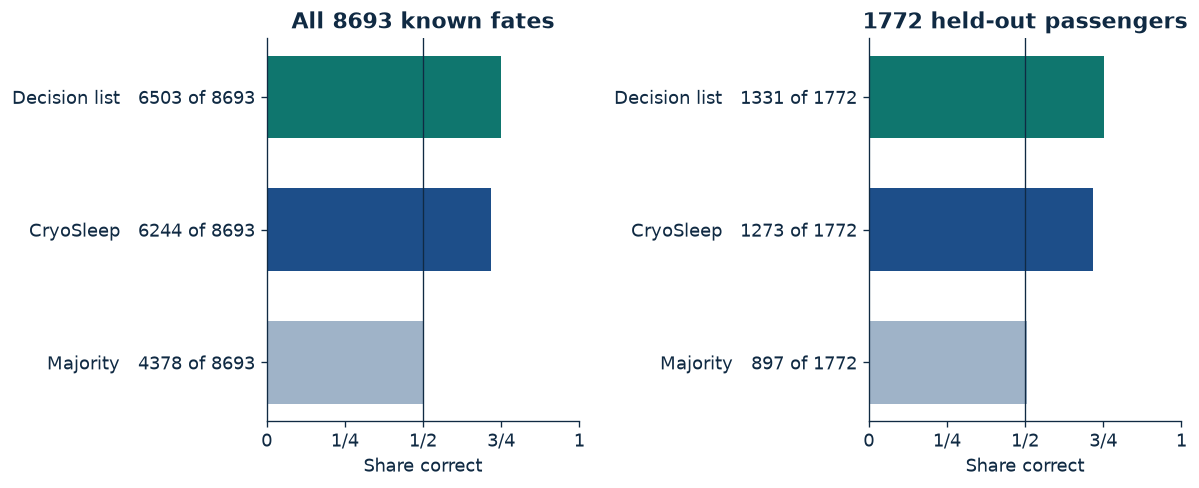

In [6]:
# The same two scores, drawn so the coin-toss floor stays visible.
import matplotlib.pyplot as plt
plt.rcParams.update({
    "axes.titleweight": "bold",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.edgecolor": "#102a43",
    "axes.labelcolor": "#102a43",
    "xtick.color": "#102a43",
    "ytick.color": "#102a43",
    "text.color": "#102a43",
})
panels = [
    (
        "All 8693 known fates",
        [("Majority", 4378, 8693), ("CryoSleep", 6244, 8693), ("Decision list", 6503, 8693)],
    ),
    (
        "1772 held-out passengers",
        [("Majority", 897, 1772), ("CryoSleep", 1273, 1772), ("Decision list", 1331, 1772)],
    ),
]
colors = ["#9fb3c8", "#1d4e89", "#0f766e"]
figure, axes = plt.subplots(1, 2, figsize=(10.2, 4.2), sharex=True)
for axis, (title, rows) in zip(axes, panels):
    positions = [0, 1, 2]
    axis.barh(
        positions,
        [hits / total for _, hits, total in rows],
        color=colors,
        height=0.62,
    )
    axis.set_yticks(
        positions,
        [f"{name}   {hits} of {total}" for name, hits, total in rows],
    )
    axis.axvline(0.5, color="#102a43", linewidth=0.8)
    axis.set_xlim(0, 1)
    axis.set_xticks([0, 0.25, 0.5, 0.75, 1])
    axis.set_xticklabels(["0", "1/4", "1/2", "3/4", "1"])
    axis.set_title(title)
axes[0].set_xlabel("Share correct")
axes[1].set_xlabel("Share correct")
figure.tight_layout()


## Pitfall

Restart and Run All rereads `data/train.csv`, `data/test.csv`, and `data/sample_submission.csv`. It does not create a fate for Nelly. A file of 4277 predictions can be written in the sample's shape; grading it requires the contest's hidden answers.

## Summary

4378 of 8693 were transported. Cryosleep alone is right on 6244. The audited list is right on 6503, and on 1331 of the 1772 passengers in held-out groups. The test fates stay outside the file.
